# Netflix Content Analysis
Netflix's content library expanded dramatically between 2016 and 2020. This project investigates how that expansion reshaped the catalog's genre mix, country representation, and content format. The dataset, sourced from DataCamp, contains 4,812 records of movies and TV shows available on Netflix through 2021, though it is heavily skewed toward movies (97%) and content released in the 2010s.

 ## Primary Question
 How has the content library of Netflix evolved over time?
 ### Secondary Questions
 Q1) Beyond action, drama, and comedy, which 3 genres constitute a significant share of Netflix's catalogue for movies released in the 1990s, 2000s, and 2010s?
 
 Q2) From which countries has Netflix acquired movies during the spike in content added between 2016 and 2020? Which genres constitute a significant share (at least 10%) of the content the countries contributed to?

 Q3) Has the average movie duration decreased across release decades?

 Q4) What does the early 2020s data suggest about content direction?

## Data Overview

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option('display.expand_frame_repr', False)
netflix_df = pd.read_csv("data/netflix_data.csv")
print("(Rows,Columns)",netflix_df.shape)
print(netflix_df.info())

(Rows,Columns) (4812, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4812 entries, 0 to 4811
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       4812 non-null   object
 1   type          4812 non-null   object
 2   title         4812 non-null   object
 3   director      4812 non-null   object
 4   cast          4812 non-null   object
 5   country       4812 non-null   object
 6   date_added    4812 non-null   object
 7   release_year  4812 non-null   int64 
 8   duration      4812 non-null   int64 
 9   description   4812 non-null   object
 10  genre         4812 non-null   object
dtypes: int64(2), object(9)
memory usage: 413.7+ KB
None


## Data Cleaning

In [20]:
netflix_df['date_added'] = pd.to_datetime(netflix_df['date_added'].astype(str).str.strip())
netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['release_decade'] = (netflix_df['release_year'] // 10) * 10
core_genres = ['Action', 'Dramas', 'Comedies']
netflix_df['genre_grouped'] = netflix_df['genre'].apply(lambda x: 'Core Genres' if x in core_genres else x)
content_counts = netflix_df['type'].value_counts().reset_index()
content_counts.columns = ['type', 'count']
content_counts['percentage'] = content_counts['count']/content_counts['count'].sum()*100
print(content_counts)
netflix_df_movies = netflix_df[netflix_df['type']=='Movie'].copy()

      type  count  percentage
0    Movie   4677   97.194514
1  TV Show    135    2.805486


1) The year the movie was added was extracted after converting the 'date_added' column to a datetime format. 
2) The release decade column was created from the release year column
3) Action, Dramas, and Comedies were grouped into Core Genres
4) Since TV shows are a minimal part of the dataset, the analysis was limited to movies

## Content distribution by release decade

This establishes the time distribution that shapes the rest of the analysis

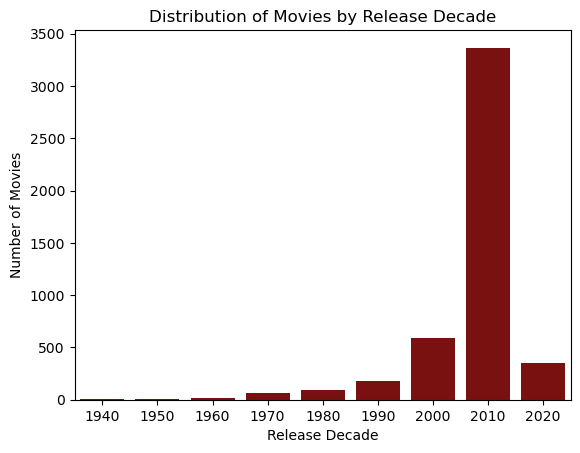

In [21]:

sns.countplot(data=netflix_df_movies, x='release_decade', color='darkred')
plt.xlabel("Release Decade")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movies by Release Decade")

plt.show()

The Netflix content library is largely dominated by movies from the 2010s.

## Q1) Beyond Action, Drama, and Comedy, which 3 genres constitute a significant share of Netflix's catalogue for movies released in the 1990s, 2000s, and 2010s?


In [22]:

genre_counts = netflix_df_movies.groupby(['release_decade','genre_grouped']).size().reset_index(name='count')
genre_counts['total'] = genre_counts.groupby('release_decade')['count'].transform('sum')
genre_counts['share'] = genre_counts['count'] / genre_counts['total']
filtered = genre_counts[genre_counts['genre_grouped'] != 'Core Genres']
top_genres_decade=filtered.sort_values(['release_decade','count'], ascending = [True,False])\
                          .groupby('release_decade')\
                          .head(5)
top_lookup = set(zip(top_genres_decade['release_decade'],top_genres_decade['genre_grouped']))
def label_genre(row):
    if row['genre_grouped'] == 'Core Genres':    
        return 'Core Genres'
    elif (row['release_decade'],row['genre_grouped']) in top_lookup:
        return row['genre_grouped']
    else:
        return 'Others'
genre_counts['final_genre'] = genre_counts.apply(label_genre, axis=1)
final_df = genre_counts.groupby(['release_decade','final_genre'])[['count','share']]\
                       .sum()\
                       .reset_index()
final_df_filtered = final_df[final_df['release_decade'].isin([1990,2000,2010])]
final_df_filtered=final_df_filtered.sort_values(['release_decade','share'], ascending = [True,False])
final_df_filtered = final_df_filtered.reset_index(drop=True)
final_df_filtered.index = final_df_filtered.index + 1
final_df_filtered.columns = ['release decade', 'genre', 'movie count', 'decade share (%)']
final_df_filtered['decade share (%)'] = final_df_filtered['decade share (%)'] * 100
final_df_filtered['decade share (%)'] = final_df_filtered['decade share (%)'].round(2)
final_df_filtered = final_df_filtered.sort_values(
    by=['release decade',  'decade share (%)'],
    ascending=[True, False]
)
final_df_filtered = final_df_filtered.reset_index(drop=True)
final_df_filtered.index = final_df_filtered.index + 1

print(final_df_filtered)


    release decade                 genre  movie count  decade share (%)
1             1990           Core Genres          132             72.13
2             1990              Children           15              8.20
3             1990        Classic Movies           15              8.20
4             1990              Stand-Up            8              4.37
5             1990             Thrillers            5              2.73
6             1990         Horror Movies            4              2.19
7             1990                Others            4              2.19
8             2000           Core Genres          436             74.02
9             2000              Children           68             11.54
10            2000         Horror Movies           27              4.58
11            2000                Others           18              3.06
12            2000         Documentaries           15              2.55
13            2000  International Movies           13           

Movies released from the 1990s, 2000s, and 2010s showed a strong presence of core genres (Action, Comedy, and Drama) as well as the Children genre. The nineties also saw Classic Movies taking up a significant share, while the 2000s saw a rise in Horror movies, and the 2010s saw a steady increase in Documentaries and Stand-Up.

## Q2) From which countries has Netflix acquired movies during the spike in content added between 2016 and 2020? Which genres constitute a significant share (at least 10%) of the content the countries contributed to?

### Distribution of movies across year added

    year added  movie count
1         2019         1309
2         2020         1177
3         2018         1098
4         2017          729
5         2016          202
6         2021           75
7         2015           47
8         2014           14
9         2011           13
10        2013            6
11        2012            3
12        2009            2
13        2010            1
14        2008            1


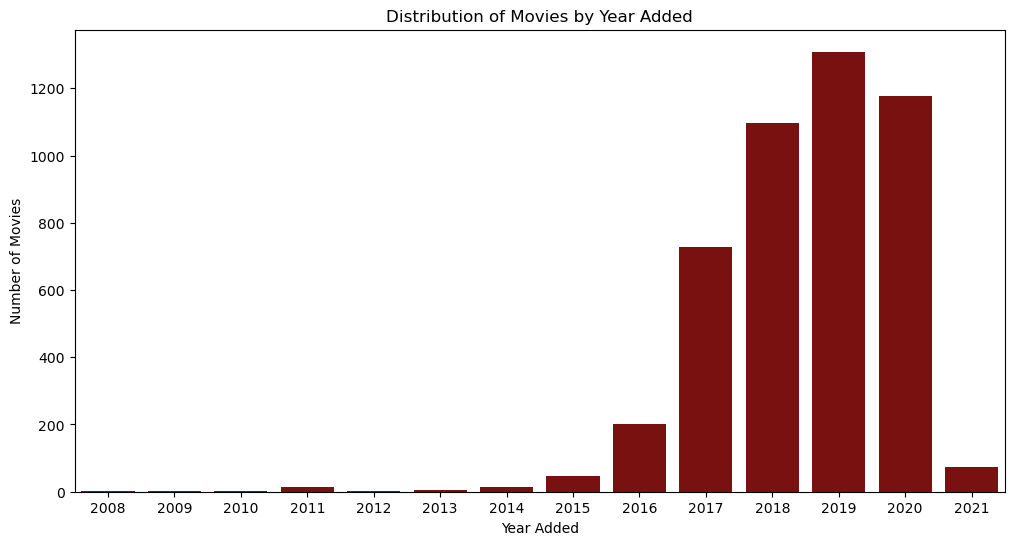

In [23]:
movie_added_count = netflix_df_movies['year_added'].value_counts().reset_index(name='movie count')
movie_added_count.index = movie_added_count.index + 1
movie_added_count.columns = ['year added', 'movie count']
print(movie_added_count)
plt.figure(figsize=(12, 6))
sns.barplot(data=movie_added_count, x='year added', y='movie count', color='darkred')
plt.xlabel("Year Added")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movies by Year Added")
plt.show()

### Movie acquisition before spike

In [24]:
netflix_movie_pre_spike = netflix_df_movies[netflix_df_movies['year_added']<2016]
pre_spike_df = netflix_movie_pre_spike.groupby(['country','genre_grouped']).size().reset_index(name='movie_count')
pre_spike_df['total'] = pre_spike_df.groupby('country')['movie_count'].transform('sum')
pre_spike_df['share'] = pre_spike_df['movie_count']/pre_spike_df['total']
filtered_pre = pre_spike_df[(pre_spike_df['share'] > 0.1) & (pre_spike_df['total']>10)]  
top_countries_pre_spike = netflix_movie_pre_spike['country'].value_counts().head(5).index
filtered_final = filtered_pre[filtered_pre['country'].isin(top_countries_pre_spike)]
filtered_final = filtered_final.reset_index(drop=True)
filtered_final.index = filtered_final.index + 1
filtered_final.columns = ['country', 'genre', 'movie count', 'total movies', 'decade share (%)']
filtered_final['decade share (%)'] = filtered_final['decade share (%)'] * 100
filtered_final['decade share (%)'] = filtered_final['decade share (%)'].round(2)
filtered_final = filtered_final.sort_values('decade share (%)', ascending=False)
filtered_final = filtered_final.reset_index(drop=True)
filtered_final.index = filtered_final.index + 1
print(filtered_final)


         country          genre  movie count  total movies  decade share (%)
1  United States    Core Genres           24            71             33.80
2  United States       Stand-Up           18            71             25.35
3  United States       Children           14            71             19.72
4  United States  Documentaries            9            71             12.68


Only the US had sufficient pre-spike data for analysis, and even that sample was small (71 movies). The genres represented, surprisingly, mainly include Children, Documentaries, Dramas, and Stand-Up.

### Movie acquisition after spike

In [25]:
netflix_movie_spike = netflix_df_movies[netflix_df_movies['year_added'].isin([2016,2017,2018,2019,2020])]
country_share = netflix_movie_spike.groupby('country').size().reset_index(name='movie_count')
country_share['total'] = country_share['movie_count'].sum()
country_share['share'] = country_share['movie_count']/country_share['total']
country_share_top_5 = country_share.sort_values('share', ascending=False).head(5)
country_share_top_5 = country_share_top_5.reset_index(drop=True)
country_share_top_5.index = country_share_top_5.index + 1
country_share_top_5.columns = ['country', 'movie count', 'total movies', 'share (%)']
country_share_top_5['share (%)'] = country_share_top_5['share (%)'] * 100
country_share_top_5['share (%)'] = country_share_top_5['share (%)'].round(2)
print(country_share_top_5)
spike_df = netflix_movie_spike.groupby(['country','genre_grouped']).size().reset_index(name='movie_count')
spike_df['total'] = spike_df.groupby('country')['movie_count'].transform('sum')
spike_df['share'] = spike_df['movie_count']/spike_df['total']
filtered = spike_df[spike_df['share'] > 0.1]  
top_countries_spike = netflix_movie_spike['country'].value_counts().head(10).index
filtered_final = filtered[filtered['country'].isin(top_countries_spike)]
filtered_final = filtered_final.reset_index(drop=True)
filtered_final.index = filtered_final.index + 1
filtered_final.columns = ['country', 'genre', 'movie count', 'total movies', 'decade share (%)']
filtered_final['decade share (%)'] = filtered_final['decade share (%)'] * 100
filtered_final['decade share (%)'] = filtered_final['decade share (%)'].round(2)
filtered_final = filtered_final.sort_values(
    by=['total movies', 'country', 'decade share (%)'],
    ascending=[False, True, False]
)
filtered_final = filtered_final.reset_index(drop=True)
filtered_final.index = filtered_final.index + 1
print(filtered_final)




          country  movie count  total movies  share (%)
1   United States         1739          4515      38.52
2           India          846          4515      18.74
3  United Kingdom          283          4515       6.27
4          Canada          146          4515       3.23
5          France          124          4515       2.75
           country                 genre  movie count  total movies  decade share (%)
1    United States           Core Genres          888          1739             51.06
2    United States              Children          250          1739             14.38
3    United States         Documentaries          193          1739             11.10
4    United States              Stand-Up          181          1739             10.41
5            India           Core Genres          744           846             87.94
6   United Kingdom           Core Genres          154           283             54.42
7   United Kingdom         Documentaries           55         

Not only did the content released in the 2010s make up a lion's share of Netflix content, but 2016 to 2020 saw the most additions to the site's catalogue. The United States, India, and the United Kingdom contributed to over 60% of the movies added. The majority of the content came from the United States within a diverse range of genres, comprising the Core Genres, Documentaries, Children, and Stand-Up. Canada and the United Kingdom had a significant share of movies from Children and Documentaries genres, respectively, apart from the core genres. India, the second-highest contributor of movies, had its content limited to the Core Genres. Movies acquired from France, Egypt, Hong Kong, the Philippines, Spain, and Turkey were primarily from the Core Genres.

## Q3) Has the average movie duration decreased across release decades?

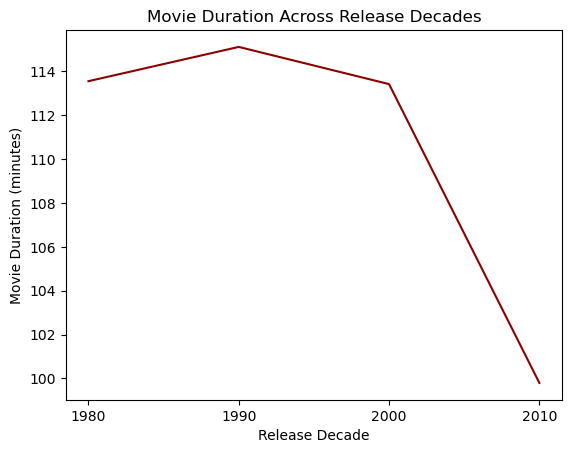

In [26]:
movies_80_start = netflix_df_movies[(netflix_df_movies['release_decade']>1970)&(netflix_df_movies['release_decade']<2020)]
movie_duration=movies_80_start.groupby('release_decade')['duration'].mean().reset_index(name="avg_duration")
sns.lineplot(data=movie_duration, x='release_decade', y='avg_duration', color='darkred')
plt.xlabel("Release Decade")
plt.ylabel("Movie Duration (minutes)")
plt.title("Movie Duration Across Release Decades")
plt.xticks(np.arange(1980, 2011, 10))
plt.show()

We analysed the movie durations across decades and it indicates that movies from later decades are of shorter duration. This could suggest that Netflix has a content strategy of acquiring newer, shorter-duration movies. This trend looks like it will continue into the 2020s, with average movie duration around 95 minutes in the preliminary data.

## Q4) What does the early 2020s data suggest about content direction?

In [27]:
final_df_filtered_2020 = final_df[final_df['release_decade'].isin([2020])]
final_df_filtered_2020 = final_df_filtered_2020.reset_index(drop=True)
final_df_filtered_2020.index = final_df_filtered_2020.index + 1
final_df_filtered_2020.columns = ['release decade', 'genre', 'movie count', 'decade share (%)']
final_df_filtered_2020['decade share (%)'] = final_df_filtered_2020['decade share (%)'] * 100
final_df_filtered_2020['decade share (%)'] = final_df_filtered_2020['decade share (%)'].round(2)
final_df_filtered_2020 = final_df_filtered_2020.sort_values('decade share (%)', ascending=False)
final_df_filtered_2020 = final_df_filtered_2020.reset_index(drop=True)
final_df_filtered_2020.index = final_df_filtered_2020.index + 1

print(final_df_filtered_2020)
netflix_2020 = netflix_df_movies[netflix_df_movies['release_decade']==2020]
df_2020 = netflix_2020.groupby(['country','genre_grouped']).size().reset_index(name='movie_count')
df_2020['total'] = df_2020.groupby('country')['movie_count'].transform('sum')
df_2020['share'] = df_2020['movie_count']/df_2020['total']
filtered = df_2020[(df_2020['share'] > 0.1) & (df_2020['total'] > 20)]
top_countries = netflix_2020['country'].value_counts().head(5).index
filtered_final = filtered[filtered['country'].isin(top_countries)]
filtered_final = filtered_final.reset_index(drop=True)
filtered_final.index = filtered_final.index + 1
filtered_final.columns = ['country', 'genre', 'movie count', 'total movies', 'decade share (%)']
filtered_final['decade share (%)'] = filtered_final['decade share (%)'] * 100
filtered_final['decade share (%)'] = filtered_final['decade share (%)'].round(2)
filtered_final = filtered_final.sort_values(
    by=['total movies', 'country', 'decade share (%)'],
    ascending=[False, True, False]
)
filtered_final = filtered_final.reset_index(drop=True)
filtered_final.index = filtered_final.index + 1
print(filtered_final)

   release decade                 genre  movie count  decade share (%)
1            2020           Core Genres          192             55.17
2            2020              Children           61             17.53
3            2020              Stand-Up           36             10.34
4            2020         Documentaries           24              6.90
5            2020         Horror Movies           19              5.46
6            2020  International Movies            8              2.30
7            2020                Others            8              2.30
         country        genre  movie count  total movies  decade share (%)
1  United States  Core Genres           75           147             51.02
2  United States     Children           32           147             21.77
3  United States     Stand-Up           20           147             13.61
4          India  Core Genres           36            50             72.00


Content from the 2020s decade was analysed separately since only data from 2020 and 2021 were available. It showed that only the United States and India made a significant contribution to the catalogue with movies from this decade. Both countries contributed to the Core Genres, while the US also supplied content from the Children and Stand-Up genres.

## Key Findings

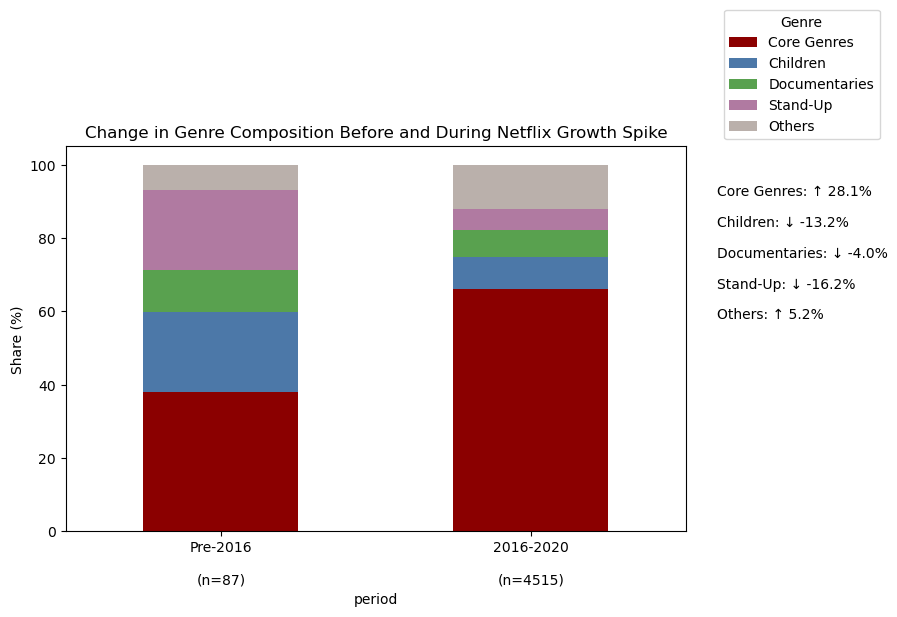

In [28]:
netflix_df_movies['period'] = netflix_df_movies['year_added'].apply(
    lambda x: 'Pre-2016' if x < 2016 
    else '2016-2020' if x <= 2020 
    else 'Post-2020'
)
target_genres = ['Core Genres', 'Children', 'Documentaries', 'Stand-Up']

netflix_df_movies['final_genre'] = netflix_df_movies['genre_grouped'].apply(
    lambda x: x if x in target_genres else 'Others'
)
genre_counts = (
    netflix_df_movies.groupby(['period','final_genre'])
      .size()
      .reset_index(name='count')
)
genre_counts['share'] = genre_counts['count'] / genre_counts.groupby('period')['count'].transform('sum')
genre_counts['share'] = genre_counts['share'] * 100
genre_counts['share'] = genre_counts['share'].round(2)

pivot = genre_counts.pivot(index='period', columns='final_genre', values='share').fillna(0)
pivot = pivot.loc[['Pre-2016', '2016-2020']]
order = ['Core Genres', 'Children', 'Documentaries', 'Stand-Up', 'Others']
pivot = pivot[order]
change = (pivot.loc['2016-2020'] - pivot.loc['Pre-2016'])
change = change.round(1)
colors = [
    '#8B0000',  
    '#4C78A8',  
    '#59A14F',  
    '#B07AA1',  
    '#BAB0AB'   
]
fig, ax = plt.subplots(figsize=(8,5))

pivot.plot(kind='bar', stacked=True, ax=ax, color=colors)

plt.xticks(rotation=0)

# Add annotations (on right side)
y_pos = 0.9  # starting height
for genre, val in change.items():
    arrow = "↑" if val > 0 else "↓"
    
    ax.text(
        1.05, y_pos,
        f"{genre}: {arrow} {val}%",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top'
    )
    
    y_pos -= 0.08  # move down for next line

plt.ylabel("Share (%)")
plt.title("Change in Genre Composition Before and During Netflix Growth Spike")
plt.xticks(rotation=0)
labels = ['Pre-2016\n\n(n=87)', '2016-2020\n\n(n=4515)']
plt.xticks(ticks=[0,1], labels=labels)
plt.legend(title="Genre", bbox_to_anchor=(1.05,1))

Netflix's pre-spike catalog was unexpectedly concentrated in non-core genres (Children, Documentaries, Stand-Up), and the 2010s acquisition spike pulled the catalog toward a core-genre-dominant profile overall, while also broadening representation of Children, Documentaries, and Stand-Up content. The number of countries from which content was acquired also increased significantly after the spike in acquisition, along with a preference for a shorter content format.

Only the US showed significant content before the spike, even though it was a small sample size. The presence of the Stand-Up genre in the genre composition of content from the US consistently before and after the spike is notable. The limited 2020s data are consistent with this pattern continuing, though sample sizes are too small to confirm. The share of Horror movies not growing into the 2010s is also surprising. The data shows that even though the absolute number of Horror movies grew, its growth in share remained negligible.

## Limitations

Content released from decades before 1990s is very minimal to be utilised for the analysis. Since the content spike is limited to 5 years, it is difficult to do a temporal analysis of Netflix's content acquisition strategy. We couldn't incorporate the 2020s decade into the main analysis due to limited data availability. We weren't able to produce a movie vs. TV show comparison since the sample size of TV shows is negligible.